In [2]:
import pandas as pd
import numpy as np
from datasets import load_dataset
import matplotlib.pyplot as plt

# loading data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

Pivot table

In [16]:
df.pivot_table(index='job_title_short', aggfunc='size')

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [17]:
df.groupby(by='job_title_short').size()

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [20]:
df.pivot_table(values='salary_year_avg', index='job_title_short', aggfunc='median')

,salary_year_avg
job_title_short,
Business Analyst,85000.0
Cloud Engineer,90000.0
Data Analyst,90000.0
Data Engineer,125000.0
Data Scientist,127500.0
Machine Learning Engineer,106415.0
Senior Data Analyst,111175.0
Senior Data Engineer,147500.0
Senior Data Scientist,155500.0


In [22]:
df.groupby('job_title_short')['salary_year_avg'].median()

job_title_short
Business Analyst              85000.0
Cloud Engineer                90000.0
Data Analyst                  90000.0
Data Engineer                125000.0
Data Scientist               127500.0
Machine Learning Engineer    106415.0
Senior Data Analyst          111175.0
Senior Data Engineer         147500.0
Senior Data Scientist        155500.0
Software Engineer             99150.0
Name: salary_year_avg, dtype: float64

In [36]:
df.pivot_table(values='salary_year_avg', columns='job_title_short', index='job_country', aggfunc='median')

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


In [ ]:
df.groupby(['job_country', 'job_title_short'])['salary_year_avg'].median()

job_country  job_title_short          
Afghanistan  Business Analyst            NaN
             Data Analyst                NaN
             Data Scientist              NaN
             Senior Data Analyst         NaN
Albania      Business Analyst            NaN
                                          ..
Zimbabwe     Machine Learning Engineer   NaN
             Senior Data Analyst         NaN
             Senior Data Engineer        NaN
             Senior Data Scientist       NaN
             Software Engineer           NaN
Name: salary_year_avg, Length: 1387, dtype: float64

In [ ]:
df.groupby(['job_country', 'job_title_short'])['salary_year_avg'].median().unstack()

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Afghanistan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Angola,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
...,...,...,...,...,...,...,...,...,...,...
Venezuela,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0
Yemen,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
top_countries_names = df['job_country'].value_counts().head(6)
top_countries = df['job_country'].value_counts().head(6).index
print(top_countries_names)
print(top_countries)

job_country
United States     206292
India              51088
United Kingdom     40375
France             39922
Germany            27694
Spain              25100
Name: count, dtype: int64
Index(['United States', 'India', 'United Kingdom', 'France', 'Germany',
       'Spain'],
      dtype='str', name='job_country')


job_title_short  Data Analyst  Data Engineer  Data Scientist
job_country                                                 
United States         90000.0       125000.0        130000.0
India                100500.0       147500.0        114008.0
United Kingdom        87750.0       110000.0        105300.0
France                69175.0        98301.5         88128.0
Germany              103750.0       147500.0        131560.0
Spain                 91977.0       133000.0         88128.0


<Axes: xlabel='job_country'>

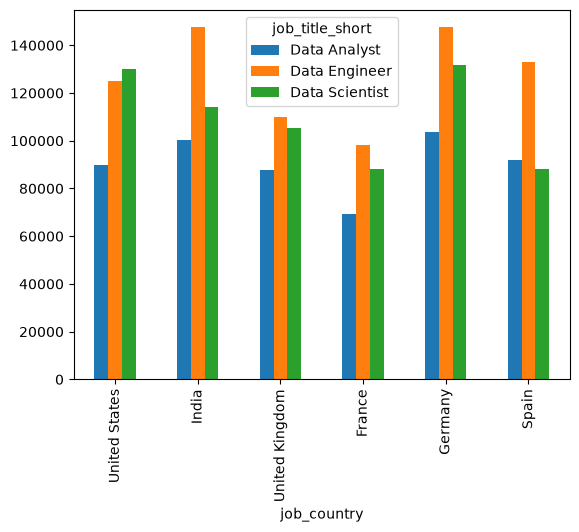

In [58]:
top_countries = df['job_country'].value_counts().head(6).index


df_job_country_salary = df.pivot_table(values='salary_year_avg', columns='job_title_short', index='job_country', aggfunc='median')
df_job_country_salary = df_job_country_salary.loc[top_countries]

job_titles = ['Data Analyst', 'Data Engineer', 'Data Scientist']
df_job_country_salary = df_job_country_salary[job_titles]

print(df_job_country_salary)
df_job_country_salary.plot(kind='bar')


job_title_short  Senior Data Scientist  Senior Data Engineer  Data Scientist
job_country                                                                 
United States                 155000.0              150000.0        130000.0
India                         149653.0              147500.0        114008.0
United Kingdom                157500.0              147500.0        105300.0
France                        157500.0              147500.0         88128.0
Germany                       157500.0              147500.0        131560.0
Spain                         157500.0              147500.0         88128.0


<Axes: xlabel='job_country'>

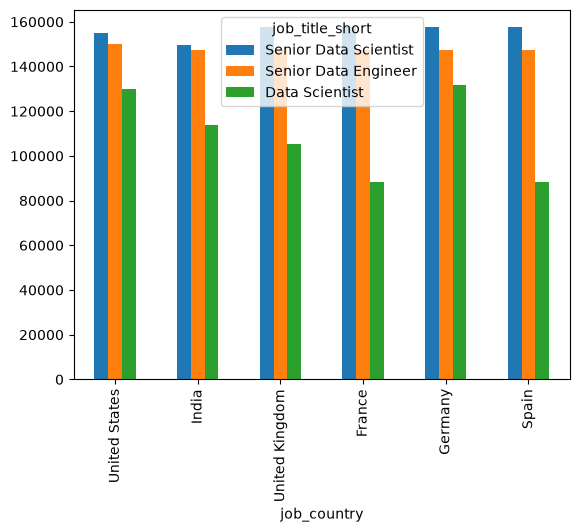

In [59]:
top_countries = df['job_country'].value_counts().head(6).index

top_job_titles = (df.groupby('job_title_short')['salary_year_avg'].median().nlargest(3).index)

df_job_country_salary = df.pivot_table(values='salary_year_avg',columns='job_title_short',index='job_country',aggfunc='median')

df_job_country_salary = df_job_country_salary.loc[top_countries, top_job_titles]

print(df_job_country_salary)
df_job_country_salary.plot(kind='bar')

In [ ]:
top_countries = df['job_country'].value_counts().head(6).index
top_job_titles = (df.groupby('job_title_short')['salary_year_avg'].median().nlargest(3).index)

df_job_country_salary = df.groupby(['job_country', 'job_title_short'])['salary_year_avg'].median().unstack()
df_job_country_salary.loc[top_countries, top_job_titles]

job_title_short,Senior Data Scientist,Senior Data Engineer,Data Scientist
job_country,,,
United States,155000.0,150000.0,130000.0
India,149653.0,147500.0,114008.0
United Kingdom,157500.0,147500.0,105300.0
France,157500.0,147500.0,88128.0
Germany,157500.0,147500.0,131560.0
Spain,157500.0,147500.0,88128.0


: 